## 首先获得待设计的骨架对应的地址，构建用于序列设计和打分的json文件

- 按照要求从PepSet中选取部分pdb，用于LigandMPNN大量设计

In [5]:
import os
import pandas as pd
from Bio.PDB import PDBParser
from collections import defaultdict

dataset = '/home/junjiechen/1_work/250401-Dpepalign/Benchmark/datasets/PepSet/Merged_PDBs'

# 记录dataset中每个复合物的肽段（L链）长度，输出每一种长度的pdb数目，保存在df中，注意：pdb只包含ATOM或者HETATM部分，没有SEQRES部分
length_dict = defaultdict(int)
parser = PDBParser(QUIET=True)

for pdb_file in os.listdir(dataset):
    if not pdb_file.endswith('.pdb'):
        continue
    structure = parser.get_structure(pdb_file, os.path.join(dataset, pdb_file))
    pep_len = None
    skip = False
    for model in structure:
        non_l_chains = [c for c in model if c.id != 'L']
        if len(non_l_chains) > 1:
            skip = True
            break
        for chain in model:
            if chain.id == 'L':
                pep_len = sum(1 for residue in chain if residue.id[0] == ' ')
                break
        if pep_len is not None:
            break
    if not skip and pep_len is not None:
        length_dict[pep_len] += 1

df = pd.DataFrame(
    sorted(length_dict.items()),
    columns=['Pep_Length', 'PDB_Count']
)
df

,Pep_Length,PDB_Count
0,5,16
1,6,15
2,7,14
3,8,17
4,9,12
5,10,13
6,11,14
7,12,13
8,13,14
9,14,9


In [6]:
df['PDB_Count'].sum()

170

In [13]:
# 接下来在每一种长度下随机选择3个pdb，复制到/home/junjiechen/1_work/250401-Dpepalign/Benchmark-Filter/datasets/PepSet_3per_length目录下，用于后续的测试
import random
import shutil
output_dir = './datasets/PepSet_dimer'
processed_database = '/home/junjiechen/1_work/250401-Dpepalign/Benchmark/datasets/PepSet/Processed_PDBs'
os.makedirs(output_dir, exist_ok=True)
length_to_pdbs = defaultdict(list)
existing_pdbs = set(os.listdir('/home/junjiechen/1_work/250401-Dpepalign/Benchmark-Filter/datasets/PepSet_3per_length'))
for pdb_file in os.listdir(dataset):
    if not pdb_file.endswith('.pdb'):
        continue
    if pdb_file in existing_pdbs:
        continue
    structure = parser.get_structure(pdb_file, os.path.join(dataset, pdb_file))
    pep_len = None
    skip = False
    for model in structure:
        non_l_chains = [c for c in model if c.id != 'L']
        if len(non_l_chains) > 1:
            skip = True
            break
        for chain in model:
            if chain.id == 'L':
                pep_len = sum(1 for residue in chain if residue.id[0] == ' ')
                break
        if pep_len is not None:
            break
    if not skip and pep_len is not None:
        length_to_pdbs[pep_len].append(pdb_file)



with open(os.path.join(output_dir, 'selected_pdbs.txt'), 'w') as f, open(os.path.join(output_dir, 'PDB.list'), 'w') as list_f:
    for pep_len, pdbs in length_to_pdbs.items():
        f.write(f'Length {pep_len}:\n')
        selected_pdbs = pdbs
        for pdb_file in selected_pdbs:
            shutil.copy(os.path.join(processed_database, pdb_file), os.path.join(output_dir, pdb_file))
            f.write(f'{pdb_file}\n')
            list_f.write(f'{pdb_file.split(".")[0]}\n')
        f.write('\n')
    f.write('\n')




### 不需要使用json文件，因为需要将每一个pdb设计的序列输出到指定的文件夹中，因此不采用pdb_path_multi的参数，而是在design_batch.sh中遍历pdb.list，将对应pdb的路径直接传入

In [ ]:
# # 生成pdb路径文件
# import os
# import json

# json_dict = {}
# dir_path = "/home/junjiechen/1_work/250401-Dpepalign/Benchmark-Filter/datasets/PepSet_3per_length"

# paths = []
# for root, dirs, files in os.walk(f'{dir_path}'):
#     for file in files:
#         if file.endswith('.pdb'):
#             full_path = os.path.join(root, file)
#             paths.append(full_path)

# # 编写json文件，格式为{"路径"：""},其中路径为complex.list中每一行的内容，去掉换行符
# """for path in paths:
#         json_dict[path] = ""
# with open(f"{dir_path}/Processed.json", "w") as json_file:
#     json.dump(json_dict, json_file, indent=4)"""   # 先不要运行这个，这种方法会将所有的骨架都设计到一个目录当中，导致目录内容过于庞大。需要在OutPut中构建不同的目录，每个目录的名称为PDB代码+温度，将对应的json文件放进去。
# for path in paths:
#     pdb_code = path.split('/')[-1].split('.')[0]
#     if not os.path.exists(f'/home/junjiechen/1_work/250401-Dpepalign/Benchmark-Filter/Output/run_json'):
#         os.makedirs(f'/home/junjiechen/1_work/250401-Dpepalign/Benchmark-Filter/Output/run_json')
#     with open(f'/home/junjiechen/1_work/250401-Dpepalign/Benchmark-Filter/Output/run_json/{pdb_code}.json', 'w', encoding='utf-8') as f:
#         json.dump({path: ""}, f, indent=4)

## 接下来对序列设计结果进行筛选
- 由于对蛋白-多肽符合物，在采用LigandMPNN-HETATM版本进行设计时不能完全考虑overall_confidence，因此需要尝试多种筛选方法，并对筛选结果用结构预测模型进行预测，分析哪种筛选方式的设计成功率更高
- 这里的“设计成功率“为**ipTM>70,pep_plddt>70,scRMSD<2.5的结果占比**

### 1. 总共设计10000条序列，并统计每一种序列出现的次数，按照次数降序，写入csv用于后续的Protenix结构预测验证

In [2]:
# 读取5d94.fa文件，统计不同序列出现的次数以及对应的overall_confidence的均值，最小值，最大值，保存到csv文件中
import pandas as pd
import os
from collections import defaultdict
from Bio.PDB import PDBParser
from Bio.SeqUtils import seq1

temperature = 0.2
res = '020'
pdbs = [pdb_file.split('.')[0] for pdb_file in os.listdir('./datasets/PepSet_3per_length') if pdb_file.endswith('.pdb')]
print(pdbs)
for pdb in pdbs:
    # pdb = '5d94'
    method_path = f'./Output/{pdb}-{temperature}T/ligandmpnn_v_32_{res}_25'

    pdb_path = "/home/junjiechen/1_work/250401-Dpepalign/Benchmark/datasets/PepSet/Merged_PDBs"
    pdb_list = os.listdir(pdb_path)
    # print(pdb_list)
    if f'{pdb}.pdb' in pdb_list:
        #读取pdb，将A链的单字母序列保存到变量sequence中，注意pdb只有ATOM或HETATM行
        parser = PDBParser(QUIET=True)
        structure = parser.get_structure(pdb, f'{pdb_path}/{pdb}.pdb')
        for model in structure:
            for chain in model:
                if chain.id != 'L':
                    pro_sequence = ''
                    for residue in chain:
                        if residue.id[0] == ' ':
                            one_letter_resname = seq1(residue.get_resname())
                            pro_sequence += one_letter_resname


    fa_file = f'{method_path}/seqs/{pdb}.fa'
    sequences = []
    confidences = defaultdict(list)

    with open(fa_file, 'r') as f:
        for i, line in enumerate(f):
            if i >= 2:
                if line.startswith('>'):
                    parts = line.strip().split(',')
                    overall_confidence = float(parts[4].split('=')[1])
                    ligand_confidence = float(parts[5].split('=')[1])
                    seq_rec = float(parts[6].split('=')[1])
                else:
                    seq = line.strip()
                    sequences.append(seq)
                    confidences[seq].append([overall_confidence, ligand_confidence, seq_rec])
    sequence_stats = []
    for seq, conf_list in confidences.items():
        count = len(conf_list)
        avg_overall_confidence = round(sum([conf[0] for conf in conf_list]) / count, 3)
        min_overall_confidence = min([conf[0] for conf in conf_list])
        max_overall_confidence = max([conf[0] for conf in conf_list])
        avg_ligand_confidence = round(sum([conf[1] for conf in conf_list]) / count, 3)
        min_ligand_confidence = min([conf[1] for conf in conf_list])
        max_ligand_confidence = max([conf[1] for conf in conf_list])
        avg_seq_rec = round(sum([conf[2] for conf in conf_list]) / count, 3)

        sequence_stats.append((pro_sequence, seq, count, avg_overall_confidence, min_overall_confidence, max_overall_confidence, avg_ligand_confidence, min_ligand_confidence, max_ligand_confidence, avg_seq_rec))



    df = pd.DataFrame(
        sequence_stats,
        columns=['Pro_Sequence', 'Pep_Sequence', 'Count', 'Average_Overall_Confidence', 'Min_Overall_Confidence', 'Max_Overall_Confidence', 'Average_Ligand_Confidence', 'Min_Ligand_Confidence', 'Max_Ligand_Confidence', 'Average_Seq_Rec']
    )
    df = df.sort_values(by='Count', ascending=False)
    df.index = range(1, len(df) + 1)
    df.to_csv(f'{method_path}/{pdb}_ranked_by_number-0.2.csv', index=True)




['6fbk', '3pe4', '2nnu', '1nrl', '2xpn', '4xek', '5v3r', '3g2s', '6f6d', '5onp', '6co4', '6b27', '1j2x', '2ht9', '3v2o', '2ivz', '4leb', '5e33', '2khh', '5xxq', '1a0n', '4pge', '4pd1', '5di8', '2cch', '5dai', '4lk9', '6g5g', '5njc', '4fii', '2cny', '2e4h', '3wgx', '1czy', '4c5a', '5tgi', '6f0w', '1pmx', '6dei', '4j2c', '1f8h', '4dg3', '2vzg', '5fml', '4z2o', '1w80', '3et3', '2aij']


In [ ]:
# 读取5d94.fa文件，统计不同序列出现的次数以及对应的overall_confidence的均值，最小值，最大值，保存到csv文件中
import pandas as pd
import os
from collections import defaultdict
from Bio.PDB import PDBParser
from Bio.SeqUtils import seq1

temperatures = [0.1]
res = '020'
pdbs = [pdb_file.split('.')[0] for pdb_file in os.listdir('./datasets/PepSet_3per_length') if pdb_file.endswith('.pdb')]
print(pdbs)

for pdb in pdbs:
    pdb_path = "/home/junjiechen/1_work/250401-Dpepalign/Benchmark/datasets/PepSet/Merged_PDBs"
    pdb_list = os.listdir(pdb_path)
    # print(pdb_list)
    if f'{pdb}.pdb' in pdb_list:
        #读取pdb，将A链的单字母序列保存到变量sequence中，注意pdb只有ATOM或HETATM行
        parser = PDBParser(QUIET=True)
        structure = parser.get_structure(pdb, f'{pdb_path}/{pdb}.pdb')
        for model in structure:
            for chain in model:
                if chain.id != 'L':
                    pro_sequence = ''
                    for residue in chain:
                        if residue.id[0] == ' ':
                            one_letter_resname = seq1(residue.get_resname())
                            pro_sequence += one_letter_resname
    sequences = []
    confidences = defaultdict(list)
    for temperature in temperatures:

        method_path = f'./Output/{pdb}-{temperature}T/ligandmpnn_v_32_{res}_25'
        fa_file = f'{method_path}/seqs/{pdb}.fa'
        
        with open(fa_file, 'r') as f:
            for i, line in enumerate(f):
                if i >= 2:
                    if line.startswith('>'):
                        parts = line.strip().split(',')
                        overall_confidence = float(parts[4].split('=')[1])
                        ligand_confidence = float(parts[5].split('=')[1])
                        seq_rec = float(parts[6].split('=')[1])
                    else:
                        seq = line.strip()
                        sequences.append(seq)
                        confidences[seq].append([overall_confidence, ligand_confidence, seq_rec])
    
    sequence_stats = []
    for seq, conf_list in confidences.items():
        count = len(conf_list)
        avg_overall_confidence = round(sum([conf[0] for conf in conf_list]) / count, 3)
        min_overall_confidence = min([conf[0] for conf in conf_list])
        max_overall_confidence = max([conf[0] for conf in conf_list])
        avg_ligand_confidence = round(sum([conf[1] for conf in conf_list]) / count, 3)
        min_ligand_confidence = min([conf[1] for conf in conf_list])
        max_ligand_confidence = max([conf[1] for conf in conf_list])
        avg_seq_rec = round(sum([conf[2] for conf in conf_list]) / count, 3)

        sequence_stats.append((pro_sequence, seq, count, avg_overall_confidence, min_overall_confidence, max_overall_confidence, avg_ligand_confidence, min_ligand_confidence, max_ligand_confidence, avg_seq_rec))



    df = pd.DataFrame(
        sequence_stats,
        columns=['Pro_Sequence', 'Pep_Sequence', 'Count', 'Average_Overall_Confidence', 'Min_Overall_Confidence', 'Max_Overall_Confidence', 'Average_Ligand_Confidence', 'Min_Ligand_Confidence', 'Max_Ligand_Confidence', 'Average_Seq_Rec']
    )
    df = df.sort_values(by='Count', ascending=False)
    df.index = range(1, len(df) + 1)
    df.to_csv(f'./Output/{pdb}-{temperature}T/ligandmpnn_v_32_{res}_25/{pdb}_ranked_by_number.csv', index=True)




['6fbk', '3pe4', '2nnu', '1nrl', '2xpn', '4xek', '5v3r', '3g2s', '6f6d', '5onp', '6co4', '6b27', '1j2x', '2ht9', '3v2o', '2ivz', '4leb', '5e33', '2khh', '5xxq', '1a0n', '4pge', '4pd1', '5di8', '2cch', '5dai', '4lk9', '6g5g', '5njc', '4fii', '2cny', '2e4h', '3wgx', '1czy', '4c5a', '5tgi', '6f0w', '1pmx', '6dei', '4j2c', '1f8h', '4dg3', '2vzg', '5fml', '4z2o', '1w80', '3et3', '2aij']


#### ps: 针对一种序列的overall_confidence打分情况，绘制直方图

Text(0, 0.5, 'Number of Designs')

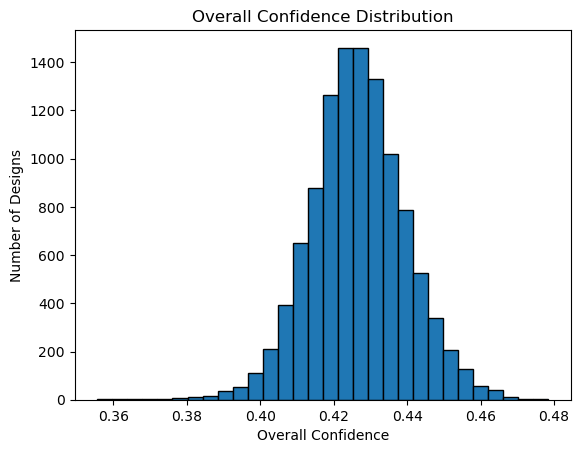

In [10]:
# 绘制指定序列的confidence
import matplotlib.pyplot as plt
fa_file = './Output/4lk9-merged/ligandmpnn_v_32_020_25/4lk9_merged.fa'
confidences = []
with open(fa_file, 'r') as f:
    current_sequence = ''
    for i, line in enumerate(f):
        if i >= 2:
            if line.startswith('>'):
                parts = line.strip().split(',')
                overall_confidence = float(parts[4].split('=')[1])
            else:
                confidences.append(overall_confidence)
plt.hist(confidences, bins=30, edgecolor='black')
plt.title('Overall Confidence Distribution')
plt.xlabel('Overall Confidence')
plt.ylabel('Number of Designs')
# plt.savefig('./Output/5d94-0.2T/ligandmpnn_v_32_020_25/overall_confidence_distribution.png')
# plt.close()

#### 随后进行Protenix结构预测

### 2. 总共设计10000条序列，对得到的序列去重之后，重新这些序列进行打分（single aa），按照overall_confidence均值降序排序，选择top10用于后续的Protenix结构预测验证

#### 26.01.22 补充：在这里额外在0.2T下设计了1000条序列，以弥补不同序列数目不足的情况。

In [ ]:
# 将相同的pdb中的seqs目录下的.fa文件合并到一个新的.fa文件中，文件保存在./Output/{pdb}-merged目录下，pdb为对应pdb的名称
import os
with open('./datasets/PepSet_3per_length/PDB.list') as f:
    pdbs = [line.strip() for line in f.readlines()]
print(pdbs)
for pdb in pdbs:
    merged_fa_path = f'./Output/{pdb}-merged/ligandmpnn_v_32_020_25'
    os.makedirs(merged_fa_path, exist_ok=True)
    merged_fa_file = os.path.join(merged_fa_path, f'{pdb}_merged.fa')
    with open(merged_fa_file, 'w') as outfile:
        for temperature in [0.1, 0.2]:
            if temperature == 0.1:
                seqs_dir = f'./Output/{pdb}-{temperature}T/ligandmpnn_v_32_020_25/seqs/{pdb}.fa'
                with open(seqs_dir, 'r') as infile:
                    for line in infile:
                        outfile.write(line)
                    outfile.write('\n')
            else:
                seqs_dir = f'./Output/{pdb}-{temperature}T/ligandmpnn_v_32_020_25/seqs/{pdb}.fa'
                with open(seqs_dir, 'r') as infile:
                    for i, line in enumerate(infile):
                        if i >= 2:
                            outfile.write(line)

['5onp', '2aij', '5e33', '1f8h', '4fii', '5njc', '1czy', '3wgx', '4leb', '1w80', '4c5a', '2e4h', '5dai', '4pge', '2khh', '4pd1', '6b27', '5xxq', '3g2s', '3v2o', '4z2o', '4j2c', '2cch', '2ht9', '4lk9', '5di8', '5v3r', '6co4', '3pe4', '1a0n', '1nrl', '2vzg', '2ivz', '3et3', '4xek', '1pmx', '6f6d', '6dei', '6fbk', '1j2x', '6f0w', '6g5g', '2cny', '4dg3', '5fml', '2nnu', '2xpn', '5tgi']


In [ ]:
# 从第三行开始读取fasta文件，将序列去重，相同的序列保留最上方的ID，将结果保存在unique文件中，将其中的蛋白名称增加下划线和id，保存unique文件
import pandas as pd
from pathlib import Path

def dedup_fasta(src_path: str, dst_path: str) -> None:
    src = Path(src_path)
    dst = Path(dst_path)

    with src.open('r', encoding='utf-8') as f:
        lines = f.readlines()

    # Skip the first two lines (start reading from the 3rd line)
    lines = lines[2:]

    unique = []
    seen = set()
    header = None
    seq_lines = []

    def commit(hdr, seq_str):
        if not hdr:
            return
        if seq_str not in seen:
            seen.add(seq_str)
            unique.append((hdr, seq_str))

    for line in lines:
        line = line.rstrip('\n')
        if line.startswith('>'):
            # commit previous record
            commit(header, ''.join(seq_lines).strip())
            header = line
            seq_lines = []
        else:
            if line.strip():
                seq_lines.append(line.strip())
    # commit last record
    commit(header, ''.join(seq_lines).strip())

    with dst.open('w', encoding='utf-8') as out:
        for (hdr, seq) in unique:
            raw = hdr[1:].strip()
            parts = raw.split(',')
            parts = [p.strip() for p in parts]
            idx = parts[1].split('=')[1]
            temperature = parts[2].split('=')[1]
            name = parts[0] if parts else ''
            new_hdr = f">{name}_{idx}_{temperature}"
            out.write(new_hdr + '\n')
            for i in range(0, len(seq), 60):
                out.write(seq[i:i + 60] + '\n')
                
pdbs = [pdb_file.split('.')[0] for pdb_file in os.listdir('./datasets/PepSet_3per_length') if pdb_file.endswith('.pdb')]
print(pdbs)
res = '020'
for pdb_code in pdbs:
    design_dir = f'./Output/{pdb_code}-merged/ligandmpnn_v_32_{res}_25'
    src_fasta = f'{design_dir}/{pdb_code}_merged.fa'
    dst_fasta = f'{design_dir}/{pdb_code}_unique.fasta'
    dedup_fasta(src_fasta, dst_fasta)


['6fbk', '3pe4', '2nnu', '1nrl', '2xpn', '4xek', '5v3r', '3g2s', '6f6d', '5onp', '6co4', '6b27', '1j2x', '2ht9', '3v2o', '2ivz', '4leb', '5e33', '2khh', '5xxq', '1a0n', '4pge', '4pd1', '5di8', '2cch', '5dai', '4lk9', '6g5g', '5njc', '4fii', '2cny', '2e4h', '3wgx', '1czy', '4c5a', '5tgi', '6f0w', '1pmx', '6dei', '4j2c', '1f8h', '4dg3', '2vzg', '5fml', '4z2o', '1w80', '3et3', '2aij']


In [10]:
for pdb_code in pdbs:
    merged_dedup_fasta = f'./Output/{pdb_code}-merged/ligandmpnn_v_32_020_25/{pdb_code}_unique.fasta'
    with open(merged_dedup_fasta, 'r') as f:
        lines = f.readlines()
        sum = len(lines)/2 - 1
        print(f'{pdb_code}: {sum} unique sequences')



6fbk: 2585.0 unique sequences
3pe4: 169.0 unique sequences
2nnu: 4902.0 unique sequences
1nrl: 3822.0 unique sequences
2xpn: 4065.0 unique sequences
4xek: 730.0 unique sequences
5v3r: 3202.0 unique sequences
3g2s: 165.0 unique sequences
6f6d: 689.0 unique sequences
5onp: 28.0 unique sequences
6co4: 2171.0 unique sequences
6b27: 308.0 unique sequences
1j2x: 4037.0 unique sequences
2ht9: 3473.0 unique sequences
3v2o: 188.0 unique sequences
2ivz: 664.0 unique sequences
4leb: 46.0 unique sequences
5e33: 28.0 unique sequences
2khh: 426.0 unique sequences
5xxq: 948.0 unique sequences
1a0n: 3268.0 unique sequences
4pge: 108.0 unique sequences
4pd1: 156.0 unique sequences
5di8: 326.0 unique sequences
2cch: 216.0 unique sequences
5dai: 136.0 unique sequences
4lk9: 593.0 unique sequences
6g5g: 1921.0 unique sequences
5njc: 128.0 unique sequences
4fii: 85.0 unique sequences
2cny: 1005.0 unique sequences
2e4h: 1283.0 unique sequences
3wgx: 81.0 unique sequences
1czy: 89.0 unique sequences
4c5a: 19

#### 对去重后的序列进行打分
- 上面完成了序列去重，这一部分在backbone目录下找到去重后的序列，编写json文件作为打分的输入文件

- 接下来进行序列打分，结果保存在score_temperature目录下

    - !! 注意，由于不同温度下设计序列后得到的骨架名称均按照pdb_id编码，因此会产生重复导致pt文件覆盖。因此需要将不同温度下的pt导入到不同的目录中

In [3]:
# 编写json文件，键为tmp.fasta中的名称，值为““
import json
import os

pdbs = [pdb_file.split('.')[0] for pdb_file in os.listdir('./datasets/PepSet_3per_length') if pdb_file.endswith('.pdb')]

res = '020'
seq_dict_1 = {}
seq_dict_2 = {}
for pdb_code in pdbs:
    design_dir = f'./Output/2000-0.1T/ligandmpnn_v_32_{res}_25'
    tmp_path = f'{design_dir}/seqs/{pdb_code}_unique.fasta'
    with open (tmp_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    # path = f"./Output/{pdb_code}-{temperature}T/ligandmpnn_v_32_{res}_25/backbones"

    for line in lines:
        line = line.rstrip('\n')
        if line.startswith('>'):
            temperature = line.split('_')[-1]
            path = f"./Output/{pdb_code}-{temperature}T/ligandmpnn_v_32_{res}_25/backbones"
            name = path + "/" + line[1:].split('_')[0] + "_" + line[1:].split('_')[1] + ".pdb"
            if temperature == '0.1':
                seq_dict_1[name] = ""
            elif temperature == '0.2':
                seq_dict_2[name] = ""
with open(f'./Output/2000-0.1T/ligandmpnn_v_32_{res}_25/score_0.1.json', 'w', encoding='utf-8') as f:
    json.dump(seq_dict_1, f, indent=4)
    # with open(f'./Output/2000-0.1T/ligandmpnn_v_32_{res}_25/score_0.2.json', 'w', encoding='utf-8') as f:
    #     json.dump(seq_dict_2, f, indent=4)

#### 分析打分结果，按照overall_confidence进行排序

最终输出的csv文件中第一列为MPNN生成的序列对应的文件名称与温度，第二列为Protein序列，第三列为Pep序列，第四列为计算后的Overall confidence均值

In [ ]:
# 按照 overall_confidence = exp[-mean_over_residues(log_probs for native sequence)] 计算 overall_confidence
import torch
import os
import pandas as pd
from Bio.PDB import PDBParser
from Bio.SeqUtils import seq1
import os


def overall_confidence_from_score_pt(pt_path: str):
    d = torch.load(pt_path, map_location="cpu")
    # inputs from score.py
    log_probs = torch.tensor(d["log_probs"], dtype=torch.float32)  # [N, L, 21]
    native_seq = torch.tensor(d["native_sequence"], dtype=torch.long)  # [L]
    mask = torch.tensor(d["mask"], dtype=torch.float32)  # [L]
    chain_mask = torch.tensor(d["chain_mask"], dtype=torch.float32)  # [L]
    m = mask * chain_mask  # [L]

    # broadcast native sequence across all samples N
    N, L, _ = log_probs.shape
    S_one_hot = torch.nn.functional.one_hot(native_seq, num_classes=21).float()  # [L, 21]
    S_one_hot = S_one_hot.unsqueeze(0).repeat(N, 1, 1)  # [N, L, 21]

    loss_per_pos = -(S_one_hot * log_probs).sum(-1)  # [N, L]
    loss = (loss_per_pos * m).sum(-1) / (m.sum() + 1e-8)  # [N]
    overall_confidence = torch.exp(-loss)  # [N]
    return overall_confidence.mean().item()


pdbs = [pdb_file.split('.')[0] for pdb_file in os.listdir('./datasets/PepSet_3per_length') if pdb_file.endswith('.pdb')]

# pdbs = ['1a0n']

ref_pdb_path = "/home/junjiechen/1_work/250401-Dpepalign/Benchmark/datasets/PepSet/Merged_PDBs"
pdb_list = os.listdir(ref_pdb_path)

res = '020'

for pdb_code in pdbs:
    design_dir = f'./Output/{pdb_code}-merged/ligandmpnn_v_32_{res}_25'
    dc = []
    for temperature in [0.1, 0.2]:
        for file in os.listdir(f'{design_dir}/score_{temperature}/'):
            if file.startswith(f'{pdb_code}') and file.endswith('.pt'):
                path = os.path.join(f'{design_dir}/score_{temperature}/', file)
                conf = overall_confidence_from_score_pt(path)
                dc.append((file.replace('.pt', '') + "_" + str(temperature), conf))
    df = pd.DataFrame(dc, columns=['pt-temperature', 'overall_confidence'])
    df_sorted = df.sort_values(by='overall_confidence', ascending=False)
    df_sorted


    # print(pdb_list)
    if f'{pdb_code}.pdb' in pdb_list:
        #读取pdb，将A链的单字母序列保存到变量sequence中，注意pdb只有ATOM或HETATM行
        parser = PDBParser(QUIET=True)
        structure = parser.get_structure(pdb_code, f'{ref_pdb_path}/{pdb_code}.pdb')
        for model in structure:
            for chain in model:
                if chain.id != 'L':
                    pro_sequence = ''
                    for residue in chain:
                        if residue.id[0] == ' ':
                            one_letter_resname = seq1(residue.get_resname())
                            pro_sequence += one_letter_resname


    top10_df = df_sorted.head(10)
    peptide_sequences = []
    name = []
    for complex in top10_df['pt-temperature']:
        complex_name = complex.split('_')[0] + '_' + complex.split('_')[1]
        temperature = complex.split('_')[2]
        peptide_sequence = ''
        structure = parser.get_structure(complex_name, f'./Output/{pdb_code}-{temperature}T/ligandmpnn_v_32_{res}_25/backbones/{complex_name}.pdb')
        for model in structure:
            for chain in model:
                if chain.id == 'L':
                    for residue in chain:
                        if residue.id[0] == ' ':
                            one_letter_resname = seq1(residue.get_resname())
                            peptide_sequence += one_letter_resname
        peptide_sequences.append(peptide_sequence)
        name.append(complex)

    top10_df.loc[:, 'Designed_Sample'] = name
    top10_df.loc[:, 'Pep_Sequence'] = peptide_sequences
    top10_df.loc[:, 'Pro_Sequence'] = pro_sequence
    top10_df = top10_df[['Designed_Sample', 'Pro_Sequence', 'Pep_Sequence', 'overall_confidence']]
    top10_df = top10_df.rename(columns={'overall_confidence': 'Average_Overall_Confidence'}).reset_index(drop=True)
    top10_df
    top10_df.to_csv(f'./Output/{pdb_code}-merged/ligandmpnn_v_32_{res}_25/{pdb_code}_rescored_top10-new.csv', index=False)



/tmp/ipykernel_2405205/3918127481.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top10_df.loc[:, 'Designed_Sample'] = name
/tmp/ipykernel_2405205/3918127481.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top10_df.loc[:, 'Pep_Sequence'] = peptide_sequences
/tmp/ipykernel_2405205/3918127481.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.p

### 3. 总共设计11000条序列（10000@0.1， 1000@0.2），选择overall_confidence最大的10条不重复序列

In [5]:
with open('./datasets/PepSet_3per_length/PDB.list') as f:
    pdbs = [line.strip() for line in f.readlines()]

for pdb in pdbs:    
    df3 = pd.read_csv(f"./Output/{pdb}-merged/ligandmpnn_v_32_020_25/ranked_by_number.csv")

    # 按照max_overall_confidence排序，保存为新的csv文件
    df3_sorted = df3.sort_values(by='Max_Overall_Confidence', ascending=False)
    df3_sorted.to_csv(f"./Output/{pdb}-merged/ligandmpnn_v_32_020_25/ranked_by_max_overall_confidence.csv", index=False)

### 4. 总共设计11000, 按照设计总数排序，取top10

In [ ]:
# 读取5d94.fa文件，统计不同序列出现的次数以及对应的overall_confidence的均值，最小值，最大值，保存到csv文件中
import pandas as pd
import os
from collections import defaultdict
from Bio.PDB import PDBParser
from Bio.SeqUtils import seq1

temperatures = [0.1, 0.2]
res = '020'
pdbs = [pdb_file.split('.')[0] for pdb_file in os.listdir('./datasets/PepSet_3per_length') if pdb_file.endswith('.pdb')]
print(pdbs)

for pdb in pdbs:
    pdb_path = "/home/junjiechen/1_work/250401-Dpepalign/Benchmark/datasets/PepSet/Merged_PDBs"
    pdb_list = os.listdir(pdb_path)
    # print(pdb_list)
    if f'{pdb}.pdb' in pdb_list:
        #读取pdb，将A链的单字母序列保存到变量sequence中，注意pdb只有ATOM或HETATM行
        parser = PDBParser(QUIET=True)
        structure = parser.get_structure(pdb, f'{pdb_path}/{pdb}.pdb')
        for model in structure:
            for chain in model:
                if chain.id != 'L':
                    pro_sequence = ''
                    for residue in chain:
                        if residue.id[0] == ' ':
                            one_letter_resname = seq1(residue.get_resname())
                            pro_sequence += one_letter_resname
    sequences = []
    confidences = defaultdict(list)
    for temperature in temperatures:

        method_path = f'./Output/{pdb}-{temperature}T/ligandmpnn_v_32_{res}_25'
        fa_file = f'{method_path}/seqs/{pdb}.fa'
        
        with open(fa_file, 'r') as f:
            for i, line in enumerate(f):
                if i >= 2:
                    if line.startswith('>'):
                        parts = line.strip().split(',')
                        overall_confidence = float(parts[4].split('=')[1])
                        ligand_confidence = float(parts[5].split('=')[1])
                        seq_rec = float(parts[6].split('=')[1])
                    else:
                        seq = line.strip()
                        sequences.append(seq)
                        confidences[seq].append([overall_confidence, ligand_confidence, seq_rec])
    
    sequence_stats = []
    for seq, conf_list in confidences.items():
        count = len(conf_list)
        avg_overall_confidence = round(sum([conf[0] for conf in conf_list]) / count, 3)
        min_overall_confidence = min([conf[0] for conf in conf_list])
        max_overall_confidence = max([conf[0] for conf in conf_list])
        avg_ligand_confidence = round(sum([conf[1] for conf in conf_list]) / count, 3)
        min_ligand_confidence = min([conf[1] for conf in conf_list])
        max_ligand_confidence = max([conf[1] for conf in conf_list])
        avg_seq_rec = round(sum([conf[2] for conf in conf_list]) / count, 3)

        sequence_stats.append((pro_sequence, seq, count, avg_overall_confidence, min_overall_confidence, max_overall_confidence, avg_ligand_confidence, min_ligand_confidence, max_ligand_confidence, avg_seq_rec))



    df = pd.DataFrame(
        sequence_stats,
        columns=['Pro_Sequence', 'Pep_Sequence', 'Count', 'Average_Overall_Confidence', 'Min_Overall_Confidence', 'Max_Overall_Confidence', 'Average_Ligand_Confidence', 'Min_Ligand_Confidence', 'Max_Ligand_Confidence', 'Average_Seq_Rec']
    )
    df = df.sort_values(by='Count', ascending=False)
    df.index = range(1, len(df) + 1)
    df.to_csv(f'./Output/{pdb}-merged/ligandmpnn_v_32_{res}_25/ranked_by_number.csv', index=True)




### 5. 总共设计11000，去重后采用autoregressive with seq进行打分

In [5]:
# 按照 overall_confidence = exp[-mean_over_residues(log_probs for native sequence)] 计算 overall_confidence
import torch
import os
import pandas as pd
from Bio.PDB import PDBParser
from Bio.SeqUtils import seq1
import os


def overall_confidence_from_score_pt(pt_path: str):
    d = torch.load(pt_path, map_location="cpu")
    # inputs from score.py
    log_probs = torch.tensor(d["log_probs"], dtype=torch.float32)  # [N, L, 21]
    native_seq = torch.tensor(d["native_sequence"], dtype=torch.long)  # [L]
    mask = torch.tensor(d["mask"], dtype=torch.float32)  # [L]
    chain_mask = torch.tensor(d["chain_mask"], dtype=torch.float32)  # [L]
    m = mask * chain_mask  # [L]

    # broadcast native sequence across all samples N
    N, L, _ = log_probs.shape
    S_one_hot = torch.nn.functional.one_hot(native_seq, num_classes=21).float()  # [L, 21]
    S_one_hot = S_one_hot.unsqueeze(0).repeat(N, 1, 1)  # [N, L, 21]

    loss_per_pos = -(S_one_hot * log_probs).sum(-1)  # [N, L]
    loss = (loss_per_pos * m).sum(-1) / (m.sum() + 1e-8)  # [N]
    overall_confidence = torch.exp(-loss)  # [N]
    return overall_confidence.mean().item()


pdbs = [pdb_file.split('.')[0] for pdb_file in os.listdir('./datasets/PepSet_3per_length') if pdb_file.endswith('.pdb')]

# pdbs = ['1a0n']

ref_pdb_path = "/home/junjiechen/1_work/250401-Dpepalign/Benchmark/datasets/PepSet/Merged_PDBs"
pdb_list = os.listdir(ref_pdb_path)

res = '020'

for pdb_code in pdbs:
    design_dir = f'./Output/{pdb_code}-merged/ligandmpnn_v_32_{res}_25'
    dc = []
    for temperature in [0.1, 0.2]:
        for file in os.listdir(f'{design_dir}/score-autoregressive_{temperature}/'):
            if file.startswith(f'{pdb_code}') and file.endswith('.pt'):
                path = os.path.join(f'{design_dir}/score-autoregressive_{temperature}/', file)
                conf = overall_confidence_from_score_pt(path)
                dc.append((file.replace('.pt', '') + "_" + str(temperature), conf))
    df = pd.DataFrame(dc, columns=['pt-temperature', 'overall_confidence'])
    df_sorted = df.sort_values(by='overall_confidence', ascending=False)
    df_sorted


    # print(pdb_list)
    if f'{pdb_code}.pdb' in pdb_list:
        #读取pdb，将A链的单字母序列保存到变量sequence中，注意pdb只有ATOM或HETATM行
        parser = PDBParser(QUIET=True)
        structure = parser.get_structure(pdb_code, f'{ref_pdb_path}/{pdb_code}.pdb')
        for model in structure:
            for chain in model:
                if chain.id != 'L':
                    pro_sequence = ''
                    for residue in chain:
                        if residue.id[0] == ' ':
                            one_letter_resname = seq1(residue.get_resname())
                            pro_sequence += one_letter_resname


    top10_df = df_sorted.head(10)
    peptide_sequences = []
    name = []
    for complex in top10_df['pt-temperature']:
        complex_name = complex.split('_')[0] + '_' + complex.split('_')[1]
        temperature = complex.split('_')[2]
        peptide_sequence = ''
        structure = parser.get_structure(complex_name, f'./Output/{pdb_code}-{temperature}T/ligandmpnn_v_32_{res}_25/backbones/{complex_name}.pdb')
        for model in structure:
            for chain in model:
                if chain.id == 'L':
                    for residue in chain:
                        if residue.id[0] == ' ':
                            one_letter_resname = seq1(residue.get_resname())
                            peptide_sequence += one_letter_resname
        peptide_sequences.append(peptide_sequence)
        name.append(complex)

    top10_df.loc[:, 'Designed_Sample'] = name
    top10_df.loc[:, 'Pep_Sequence'] = peptide_sequences
    top10_df.loc[:, 'Pro_Sequence'] = pro_sequence
    top10_df = top10_df[['Designed_Sample', 'Pro_Sequence', 'Pep_Sequence', 'overall_confidence']]
    top10_df = top10_df.rename(columns={'overall_confidence': 'Average_Overall_Confidence'}).reset_index(drop=True)
    top10_df
    top10_df.to_csv(f'./Output/{pdb_code}-merged/ligandmpnn_v_32_{res}_25/{pdb_code}_rescored_top10-autoregressive.csv', index=False)



/tmp/ipykernel_2828334/2836642429.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top10_df.loc[:, 'Designed_Sample'] = name
/tmp/ipykernel_2828334/2836642429.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top10_df.loc[:, 'Pep_Sequence'] = peptide_sequences
/tmp/ipykernel_2828334/2836642429.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.p

### 6. 总共设计2000，去重后采用autoregressive with seq进行打分,取均值保存在csv中

In [9]:
# 按照 overall_confidence = exp[-mean_over_residues(log_probs for native sequence)] 计算 overall_confidence
import torch
import os
import pandas as pd
from Bio.PDB import PDBParser
from Bio.SeqUtils import seq1
import os


def overall_confidence_from_score_pt(pt_path: str):
    d = torch.load(pt_path, map_location="cpu")
    # inputs from score.py
    log_probs = torch.tensor(d["log_probs"], dtype=torch.float32)  # [N, L, 21]
    native_seq = torch.tensor(d["native_sequence"], dtype=torch.long)  # [L]
    mask = torch.tensor(d["mask"], dtype=torch.float32)  # [L]
    chain_mask = torch.tensor(d["chain_mask"], dtype=torch.float32)  # [L]
    m = mask * chain_mask  # [L]

    # broadcast native sequence across all samples N
    N, L, _ = log_probs.shape
    S_one_hot = torch.nn.functional.one_hot(native_seq, num_classes=21).float()  # [L, 21]
    S_one_hot = S_one_hot.unsqueeze(0).repeat(N, 1, 1)  # [N, L, 21]

    loss_per_pos = -(S_one_hot * log_probs).sum(-1)  # [N, L]
    loss = (loss_per_pos * m).sum(-1) / (m.sum() + 1e-8)  # [N]
    overall_confidence = torch.exp(-loss)  # [N]
    return overall_confidence.mean().item()


pdbs = [pdb_file.split('.')[0] for pdb_file in os.listdir('./datasets/PepSet_3per_length') if pdb_file.endswith('.pdb')]

# pdbs = ['1a0n']

ref_pdb_path = "/home/junjiechen/1_work/250401-Dpepalign/Benchmark/datasets/PepSet/Merged_PDBs"
pdb_list = os.listdir(ref_pdb_path)

res = '020'

for pdb_code in pdbs:
    design_dir = f'./Output/2000-0.1T/ligandmpnn_v_32_{res}_25'
    dc = []
    for temperature in [0.1]:
        for file in os.listdir(f'{design_dir}/score_{temperature}/'):
            if file.startswith(f'{pdb_code}') and file.endswith('.pt'):
                path = os.path.join(f'{design_dir}/score_{temperature}/', file)
                conf = overall_confidence_from_score_pt(path)
                dc.append((file.replace('.pt', '') + "_" + str(temperature), conf))
    df = pd.DataFrame(dc, columns=['pt_temperature', 'overall_confidence'])
    df_sorted = df.sort_values(by='overall_confidence', ascending=False)
    df_sorted


    # print(pdb_list)
    if f'{pdb_code}.pdb' in pdb_list:
        #读取pdb，将A链的单字母序列保存到变量sequence中，注意pdb只有ATOM或HETATM行
        parser = PDBParser(QUIET=True)
        structure = parser.get_structure(pdb_code, f'{ref_pdb_path}/{pdb_code}.pdb')
        for model in structure:
            for chain in model:
                if chain.id != 'L':
                    pro_sequence = ''
                    for residue in chain:
                        if residue.id[0] == ' ':
                            one_letter_resname = seq1(residue.get_resname())
                            pro_sequence += one_letter_resname


    top10_df = df_sorted.head(10)
    peptide_sequences = []
    name = []
    for complex in top10_df['pt_temperature']:
        complex_name = complex.split('_')[0] + '_' + complex.split('_')[1]
        temperature = complex.split('_')[2]
        peptide_sequence = ''
        structure = parser.get_structure(complex_name, f'./Output/2000-0.1T/ligandmpnn_v_32_{res}_25/backbones/{complex_name}.pdb')
        for model in structure:
            for chain in model:
                if chain.id == 'L':
                    for residue in chain:
                        if residue.id[0] == ' ':
                            one_letter_resname = seq1(residue.get_resname())
                            peptide_sequence += one_letter_resname
        peptide_sequences.append(peptide_sequence)
        name.append(complex)

    top10_df.loc[:, 'Designed_Sample'] = name
    top10_df.loc[:, 'Pep_Sequence'] = peptide_sequences
    top10_df.loc[:, 'Pro_Sequence'] = pro_sequence
    top10_df = top10_df[['Designed_Sample', 'Pro_Sequence', 'Pep_Sequence', 'overall_confidence']]
    top10_df = top10_df.rename(columns={'overall_confidence': 'Average_Overall_Confidence'}).reset_index(drop=True)
    # top10_df
    os.system(f'mkdir -p ./Output/2000-0.1T/ligandmpnn_v_32_{res}_25/rescored_seq_stats-new/')
    top10_df.to_csv(f'./Output/2000-0.1T/ligandmpnn_v_32_{res}_25/rescored_seq_stats-new/{pdb_code}_rescored_top10.csv', index=False)



/tmp/ipykernel_341508/2106081230.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top10_df.loc[:, 'Designed_Sample'] = name
/tmp/ipykernel_341508/2106081230.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top10_df.loc[:, 'Pep_Sequence'] = peptide_sequences
/tmp/ipykernel_341508/2106081230.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyda

### 7. 总共设计2000，去重后重新打分100次，autoregressive，选择平均confidence最高的10条序列用于结构预测

In [4]:
# 按照 overall_confidence = exp[-mean_over_residues(log_probs for native sequence)] 计算 overall_confidence
import torch
import os
import pandas as pd
from Bio.PDB import PDBParser
from Bio.SeqUtils import seq1
import os


def overall_confidence_from_score_pt(pt_path: str):
    d = torch.load(pt_path, map_location="cpu")
    # inputs from score.py
    log_probs = torch.tensor(d["log_probs"], dtype=torch.float32)  # [N, L, 21]
    native_seq = torch.tensor(d["native_sequence"], dtype=torch.long)  # [L]
    mask = torch.tensor(d["mask"], dtype=torch.float32)  # [L]
    chain_mask = torch.tensor(d["chain_mask"], dtype=torch.float32)  # [L]
    m = mask * chain_mask  # [L]

    # broadcast native sequence across all samples N
    N, L, _ = log_probs.shape
    S_one_hot = torch.nn.functional.one_hot(native_seq, num_classes=21).float()  # [L, 21]
    S_one_hot = S_one_hot.unsqueeze(0).repeat(N, 1, 1)  # [N, L, 21]

    loss_per_pos = -(S_one_hot * log_probs).sum(-1)  # [N, L]
    loss = (loss_per_pos * m).sum(-1) / (m.sum() + 1e-8)  # [N]
    overall_confidence = torch.exp(-loss)  # [N]
    return overall_confidence.mean().item()


pdbs = [pdb_file.split('.')[0] for pdb_file in os.listdir('./datasets/PepSet_3per_length') if pdb_file.endswith('.pdb')]

# pdbs = ['1a0n']

ref_pdb_path = "/home/junjiechen/1_work/250401-Dpepalign/Benchmark/datasets/PepSet/Merged_PDBs"
pdb_list = os.listdir(ref_pdb_path)

res = '020'

for pdb_code in pdbs:
    design_dir = f'./Output/2000-0.1T/ligandmpnn_v_32_{res}_25'
    dc = []
    for temperature in [0.1]:
        for file in os.listdir(f'{design_dir}/score-100_{temperature}/'):
            if file.startswith(f'{pdb_code}') and file.endswith('.pt'):
                path = os.path.join(f'{design_dir}/score-100_{temperature}/', file)
                conf = overall_confidence_from_score_pt(path)
                dc.append((file.replace('.pt', '') + "_" + str(temperature), conf))
    df = pd.DataFrame(dc, columns=['pt_temperature', 'overall_confidence'])
    df_sorted = df.sort_values(by='overall_confidence', ascending=False)
    df_sorted


    # print(pdb_list)
    if f'{pdb_code}.pdb' in pdb_list:
        #读取pdb，将A链的单字母序列保存到变量sequence中，注意pdb只有ATOM或HETATM行
        parser = PDBParser(QUIET=True)
        structure = parser.get_structure(pdb_code, f'{ref_pdb_path}/{pdb_code}.pdb')
        for model in structure:
            for chain in model:
                if chain.id != 'L':
                    pro_sequence = ''
                    for residue in chain:
                        if residue.id[0] == ' ':
                            one_letter_resname = seq1(residue.get_resname())
                            pro_sequence += one_letter_resname


    top10_df = df_sorted.head(10)
    peptide_sequences = []
    name = []
    for complex in top10_df['pt_temperature']:
        complex_name = complex.split('_')[0] + '_' + complex.split('_')[1]
        temperature = complex.split('_')[2]
        peptide_sequence = ''
        structure = parser.get_structure(complex_name, f'./Output/2000-0.1T/ligandmpnn_v_32_{res}_25/backbones/{complex_name}.pdb')
        for model in structure:
            for chain in model:
                if chain.id == 'L':
                    for residue in chain:
                        if residue.id[0] == ' ':
                            one_letter_resname = seq1(residue.get_resname())
                            peptide_sequence += one_letter_resname
        peptide_sequences.append(peptide_sequence)
        name.append(complex)

    top10_df.loc[:, 'Designed_Sample'] = name
    top10_df.loc[:, 'Pep_Sequence'] = peptide_sequences
    top10_df.loc[:, 'Pro_Sequence'] = pro_sequence
    top10_df = top10_df[['Designed_Sample', 'Pro_Sequence', 'Pep_Sequence', 'overall_confidence']]
    top10_df = top10_df.rename(columns={'overall_confidence': 'Average_Overall_Confidence'}).reset_index(drop=True)
    # top10_df
    os.system(f'mkdir -p ./Output/2000-0.1T/ligandmpnn_v_32_{res}_25/rescored-100_seq_stats/')
    top10_df.to_csv(f'./Output/2000-0.1T/ligandmpnn_v_32_{res}_25/rescored-100_seq_stats/{pdb_code}_rescored-100_top10.csv', index=False)



/tmp/ipykernel_2828334/2046865739.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top10_df.loc[:, 'Designed_Sample'] = name
/tmp/ipykernel_2828334/2046865739.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top10_df.loc[:, 'Pep_Sequence'] = peptide_sequences
/tmp/ipykernel_2828334/2046865739.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.p

### 8. 对0.2T设计的2000条序列进行筛选，按照均值排序，打分，筛选top10

In [18]:
# 将相同的pdb中的seqs目录下的.fa文件合并到一个新的.fa文件中，文件保存在./Output/{pdb}-merged目录下，pdb为对应pdb的名称
import os
with open('./datasets/PepSet_3per_length/PDB.list') as f:
    pdbs = [line.strip() for line in f.readlines()]
print(pdbs)
for pdb in pdbs:
    merged_fa_path = f'./Output/{pdb}-0.2T-merged/ligandmpnn_v_32_020_25'
    os.makedirs(merged_fa_path, exist_ok=True)
    merged_fa_file = os.path.join(merged_fa_path, f'{pdb}_merged.fa')
    with open(merged_fa_file, 'w') as outfile:
        for trait in [1, 2]:
            if trait == 1:
                seqs_dir = f'./Output/{pdb}-0.2T/ligandmpnn_v_32_020_25/seqs/{pdb}.fa'
                with open(seqs_dir, 'r') as infile:
                    for line in infile:
                        outfile.write(line)
                    outfile.write('\n')
            else:
                seqs_dir = f'./Output/{pdb}-0.2T-2/ligandmpnn_v_32_020_25/seqs/{pdb}.fa'
                with open(seqs_dir, 'r') as infile:
                    for i, line in enumerate(infile):
                        if i >= 2:
                            outfile.write(line)

['5onp', '2aij', '5e33', '1f8h', '4fii', '5njc', '1czy', '3wgx', '4leb', '1w80', '4c5a', '2e4h', '5dai', '4pge', '2khh', '4pd1', '6b27', '5xxq', '3g2s', '3v2o', '4z2o', '4j2c', '2cch', '2ht9', '4lk9', '5di8', '5v3r', '6co4', '3pe4', '1a0n', '1nrl', '2vzg', '2ivz', '3et3', '4xek', '1pmx', '6f6d', '6dei', '6fbk', '1j2x', '6f0w', '6g5g', '2cny', '4dg3', '5fml', '2nnu', '2xpn', '5tgi']


In [20]:
# 从第三行开始读取fasta文件，将序列去重，相同的序列保留最上方的ID，将结果保存在unique文件中，将其中的蛋白名称增加下划线和id，保存unique文件
import pandas as pd
from pathlib import Path

def dedup_fasta(src_path: str, dst_path: str) -> None:
    src = Path(src_path)
    dst = Path(dst_path)

    with src.open('r', encoding='utf-8') as f:
        lines = f.readlines()

    # Skip the first two lines (start reading from the 3rd line)
    lines = lines[2:]

    unique = []
    seen = set()
    header = None
    seq_lines = []

    def commit(hdr, seq_str):
        if not hdr:
            return
        if seq_str not in seen:
            seen.add(seq_str)
            unique.append((hdr, seq_str))

    for line in lines:
        line = line.rstrip('\n')
        if line.startswith('>'):
            # commit previous record
            commit(header, ''.join(seq_lines).strip())
            header = line
            seq_lines = []
        else:
            if line.strip():
                seq_lines.append(line.strip())
    # commit last record
    commit(header, ''.join(seq_lines).strip())

    with dst.open('w', encoding='utf-8') as out:
        for (hdr, seq) in unique:
            raw = hdr[1:].strip()
            parts = raw.split(',')
            parts = [p.strip() for p in parts]
            idx = parts[1].split('=')[1]
            temperature = parts[2].split('=')[1]
            seed = parts[3].split('=')[1]
            name = parts[0] if parts else ''
            new_hdr = f">{name}_{idx}_{temperature}_{seed}"
            out.write(new_hdr + '\n')
            for i in range(0, len(seq), 60):
                out.write(seq[i:i + 60] + '\n')
                
pdbs = [pdb_file.split('.')[0] for pdb_file in os.listdir('./datasets/PepSet_3per_length') if pdb_file.endswith('.pdb')]
print(pdbs)
res = '020'
for pdb_code in pdbs:
    design_dir = f'./Output/{pdb_code}-merged-0.2-1_2/ligandmpnn_v_32_{res}_25'
    src_fasta = f'{design_dir}/{pdb_code}_merged.fa'
    dst_fasta = f'{design_dir}/{pdb_code}_unique.fasta'
    dedup_fasta(src_fasta, dst_fasta)

['6fbk', '3pe4', '2nnu', '1nrl', '2xpn', '4xek', '5v3r', '3g2s', '6f6d', '5onp', '6co4', '6b27', '1j2x', '2ht9', '3v2o', '2ivz', '4leb', '5e33', '2khh', '5xxq', '1a0n', '4pge', '4pd1', '5di8', '2cch', '5dai', '4lk9', '6g5g', '5njc', '4fii', '2cny', '2e4h', '3wgx', '1czy', '4c5a', '5tgi', '6f0w', '1pmx', '6dei', '4j2c', '1f8h', '4dg3', '2vzg', '5fml', '4z2o', '1w80', '3et3', '2aij']


In [26]:
# 编写json文件，键为tmp.fasta中的名称，值为““
import json
import os

pdbs = [pdb_file.split('.')[0] for pdb_file in os.listdir('./datasets/PepSet_3per_length') if pdb_file.endswith('.pdb')]

res = '020'

for pdb_code in pdbs:
    seq_dict1 = {}
    seq_dict2 = {}
    design_dir = f'./Output/{pdb_code}-merged-0.2-1_2/ligandmpnn_v_32_{res}_25'
    tmp_path = f'{design_dir}/{pdb_code}_unique.fasta'
    with open (tmp_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    

    for line in lines:
        line = line.rstrip('\n')
        if line.startswith('>'):
            seed = line.split('_')[-1]
            temperature = line.split('_')[-2]
            if seed == '111':
                path = f"./Output/{pdb_code}-0.2T/ligandmpnn_v_32_{res}_25/backbones"
                name = path + "/" + line[1:].split('_')[0] + "_" + line[1:].split('_')[1] + ".pdb"
                seq_dict1[name] = ""
                
            elif seed == '42':
                path = f"./Output/{pdb_code}-0.2T-2/ligandmpnn_v_32_{res}_25/backbones"
                name = path + "/" + line[1:].split('_')[0] + "_" + line[1:].split('_')[1] + ".pdb"
                seq_dict2[name] = ""
    with open(f'{design_dir}/score1.json', 'w', encoding='utf-8') as f:
        json.dump(seq_dict1, f, indent=4)
    with open(f'{design_dir}/score2.json', 'w', encoding='utf-8') as f:
        json.dump(seq_dict2, f, indent=4)

In [ ]:
# 按照 overall_confidence = exp[-mean_over_residues(log_probs for native sequence)] 计算 overall_confidence
import torch
import os
import pandas as pd
from Bio.PDB import PDBParser
from Bio.SeqUtils import seq1
import os


def overall_confidence_from_score_pt(pt_path: str):
    d = torch.load(pt_path, map_location="cpu")
    # inputs from score.py
    log_probs = torch.tensor(d["log_probs"], dtype=torch.float32)  # [N, L, 21]
    native_seq = torch.tensor(d["native_sequence"], dtype=torch.long)  # [L]
    mask = torch.tensor(d["mask"], dtype=torch.float32)  # [L]
    chain_mask = torch.tensor(d["chain_mask"], dtype=torch.float32)  # [L]
    m = mask * chain_mask  # [L]

    # broadcast native sequence across all samples N
    N, L, _ = log_probs.shape
    S_one_hot = torch.nn.functional.one_hot(native_seq, num_classes=21).float()  # [L, 21]
    S_one_hot = S_one_hot.unsqueeze(0).repeat(N, 1, 1)  # [N, L, 21]

    loss_per_pos = -(S_one_hot * log_probs).sum(-1)  # [N, L]
    loss = (loss_per_pos * m).sum(-1) / (m.sum() + 1e-8)  # [N]
    overall_confidence = torch.exp(-loss)  # [N]
    return overall_confidence.mean().item()


pdbs = [pdb_file.split('.')[0] for pdb_file in os.listdir('./datasets/PepSet_3per_length') if pdb_file.endswith('.pdb')]

# pdbs = ['1a0n']

ref_pdb_path = "/home/junjiechen/1_work/250401-Dpepalign/Benchmark/datasets/PepSet/Merged_PDBs"
pdb_list = os.listdir(ref_pdb_path)

res = '020'
temperature = '0.2'

for pdb_code in pdbs:
    design_dir1 = f'./Output/{pdb_code}-{temperature}T/ligandmpnn_v_32_{res}_25'
    design_dir2 = f'./Output/{pdb_code}-{temperature}T-2/ligandmpnn_v_32_{res}_25'
    score_dir = f'./Output/{pdb_code}-merged-0.2-1_2/ligandmpnn_v_32_{res}_25'
    dc = []
    for part in [1, 2]:
        for file in os.listdir(f'{score_dir}/score-autoregressive_{part}/'):
            if file.startswith(f'{pdb_code}') and file.endswith('.pt'):
                path = os.path.join(f'{score_dir}/score-autoregressive_{part}/', file)
                conf = overall_confidence_from_score_pt(path)
                dc.append((file.replace('.pt', '') + "_" + str(part), conf))
    df = pd.DataFrame(dc, columns=['pt_part', 'overall_confidence'])
    df_sorted = df.sort_values(by='overall_confidence', ascending=False)
    # df_sorted


    # print(pdb_list)
    if f'{pdb_code}.pdb' in pdb_list:
        #读取pdb，将A链的单字母序列保存到变量sequence中，注意pdb只有ATOM或HETATM行
        parser = PDBParser(QUIET=True)
        structure = parser.get_structure(pdb_code, f'{ref_pdb_path}/{pdb_code}.pdb')
        for model in structure:
            for chain in model:
                if chain.id != 'L':
                    pro_sequence = ''
                    for residue in chain:
                        if residue.id[0] == ' ':
                            one_letter_resname = seq1(residue.get_resname())
                            pro_sequence += one_letter_resname


    top10_df = df_sorted.head(10)
    peptide_sequences = []
    name = []
    for complex in top10_df['pt_part']:
        complex_name = complex.split('_')[0] + '_' + complex.split('_')[1]
        part = complex.split('_')[2]
        peptide_sequence = ''
        if part == '1':
            structure = parser.get_structure(complex_name, f'{design_dir1}/backbones/{complex_name}.pdb')
        else:
            structure = parser.get_structure(complex_name, f'{design_dir2}/backbones/{complex_name}.pdb')
        for model in structure:
            for chain in model:
                if chain.id == 'L':
                    for residue in chain:
                        if residue.id[0] == ' ':
                            one_letter_resname = seq1(residue.get_resname())
                            peptide_sequence += one_letter_resname
        peptide_sequences.append(peptide_sequence)
        name.append(complex)

    top10_df.loc[:, 'Designed_Sample'] = name
    top10_df.loc[:, 'Pep_Sequence'] = peptide_sequences
    top10_df.loc[:, 'Pro_Sequence'] = pro_sequence
    top10_df = top10_df[['Designed_Sample', 'Pro_Sequence', 'Pep_Sequence', 'overall_confidence']]
    top10_df = top10_df.rename(columns={'overall_confidence': 'Average_Overall_Confidence'}).reset_index(drop=True)
    # top10_df
    # os.system(f'mkdir -p ./Output/2000-0.1T/ligandmpnn_v_32_{res}_25/rescored_seq_stats-new/')
    top10_df.to_csv(f'./{score_dir}/{pdb_code}_rescored_top10-autoregressive.csv', index=False)



,pt_part,overall_confidence
342,6g5g_56_1,0.333329
533,6g5g_572_1,0.333219
447,6g5g_295_1,0.331912
343,6g5g_48_1,0.331238
486,6g5g_100_1,0.330341
...,...,...
558,6g5g_467_1,0.246072
183,6g5g_346_1,0.244603
263,6g5g_333_1,0.242108
1015,6g5g_923_2,0.234557


### 9.设计2000条（0.1T），去重后按照max overall confidence排序，选择top10用于结构预测

In [31]:
# 读取fa文件，统计不同序列出现的次数以及对应的overall_confidence的均值，最小值，最大值，保存到csv文件中
import pandas as pd
import os
from collections import defaultdict
from Bio.PDB import PDBParser
from Bio.SeqUtils import seq1

temperature = 0.1
res = '020'
pdbs = [pdb_file.split('.')[0] for pdb_file in os.listdir('./datasets/PepSet_3per_length') if pdb_file.endswith('.pdb')]
print(pdbs)
for pdb in pdbs:
    method_path = f'./Output/2000-{temperature}T/ligandmpnn_v_32_{res}_25'

    pdb_path = "/home/junjiechen/1_work/250401-Dpepalign/Benchmark/datasets/PepSet/Merged_PDBs"
    pdb_list = os.listdir(pdb_path)
    # print(pdb_list)
    if f'{pdb}.pdb' in pdb_list:
        #读取pdb，将A链的单字母序列保存到变量sequence中，注意pdb只有ATOM或HETATM行
        parser = PDBParser(QUIET=True)
        structure = parser.get_structure(pdb, f'{pdb_path}/{pdb}.pdb')
        for model in structure:
            for chain in model:
                if chain.id != 'L':
                    pro_sequence = ''
                    for residue in chain:
                        if residue.id[0] == ' ':
                            one_letter_resname = seq1(residue.get_resname())
                            pro_sequence += one_letter_resname


    fa_file = f'{method_path}/seqs/{pdb}.fa'
    sequences = []
    confidences = defaultdict(list)

    with open(fa_file, 'r') as f:
        for i, line in enumerate(f):
            if i >= 2:
                if line.startswith('>'):
                    parts = line.strip().split(',')
                    overall_confidence = float(parts[4].split('=')[1])
                    ligand_confidence = float(parts[5].split('=')[1])
                    seq_rec = float(parts[6].split('=')[1])
                else:
                    seq = line.strip()
                    sequences.append(seq)
                    confidences[seq].append([overall_confidence, ligand_confidence, seq_rec])
    sequence_stats = []
    for seq, conf_list in confidences.items():
        count = len(conf_list)
        avg_overall_confidence = round(sum([conf[0] for conf in conf_list]) / count, 3)
        min_overall_confidence = min([conf[0] for conf in conf_list])
        max_overall_confidence = max([conf[0] for conf in conf_list])
        avg_ligand_confidence = round(sum([conf[1] for conf in conf_list]) / count, 3)
        min_ligand_confidence = min([conf[1] for conf in conf_list])
        max_ligand_confidence = max([conf[1] for conf in conf_list])
        avg_seq_rec = round(sum([conf[2] for conf in conf_list]) / count, 3)

        sequence_stats.append((pro_sequence, seq, count, avg_overall_confidence, min_overall_confidence, max_overall_confidence, avg_ligand_confidence, min_ligand_confidence, max_ligand_confidence, avg_seq_rec))



    df = pd.DataFrame(
        sequence_stats,
        columns=['Pro_Sequence', 'Pep_Sequence', 'Count', 'Average_Overall_Confidence', 'Min_Overall_Confidence', 'Max_Overall_Confidence', 'Average_Ligand_Confidence', 'Min_Ligand_Confidence', 'Max_Ligand_Confidence', 'Average_Seq_Rec']
    )
    df = df.sort_values(by='Max_Overall_Confidence', ascending=False)
    df.index = range(1, len(df) + 1)
    os.makedirs(f'{method_path}/ranked_by_Max_Overall_Confidence', exist_ok=True)
    df.to_csv(f'{method_path}/ranked_by_Max_Overall_Confidence/{pdb}_ranked_by_Max_Overall_Confidence-0.1.csv', index=True)


['6fbk', '3pe4', '2nnu', '1nrl', '2xpn', '4xek', '5v3r', '3g2s', '6f6d', '5onp', '6co4', '6b27', '1j2x', '2ht9', '3v2o', '2ivz', '4leb', '5e33', '2khh', '5xxq', '1a0n', '4pge', '4pd1', '5di8', '2cch', '5dai', '4lk9', '6g5g', '5njc', '4fii', '2cny', '2e4h', '3wgx', '1czy', '4c5a', '5tgi', '6f0w', '1pmx', '6dei', '4j2c', '1f8h', '4dg3', '2vzg', '5fml', '4z2o', '1w80', '3et3', '2aij']


### 10. 2000 seqs, ranked by counts

In [1]:
# 统计不同序列出现的次数以及对应的overall_confidence的均值，最小值，最大值，保存到csv文件中
import pandas as pd
import os
from collections import defaultdict
from Bio.PDB import PDBParser
from Bio.SeqUtils import seq1

temperatures = [0.1]
res = '020'
pdbs = [pdb_file.split('.')[0] for pdb_file in os.listdir('./datasets/PepSet_3per_length') if pdb_file.endswith('.pdb')]
print(pdbs)

for pdb in pdbs:
    pdb_path = "/home/junjiechen/1_work/250401-Dpepalign/Benchmark/datasets/PepSet/Merged_PDBs"
    pdb_list = os.listdir(pdb_path)
    # print(pdb_list)
    if f'{pdb}.pdb' in pdb_list:
        #读取pdb，将A链的单字母序列保存到变量sequence中，注意pdb只有ATOM或HETATM行
        parser = PDBParser(QUIET=True)
        structure = parser.get_structure(pdb, f'{pdb_path}/{pdb}.pdb')
        for model in structure:
            for chain in model:
                if chain.id != 'L':
                    pro_sequence = ''
                    for residue in chain:
                        if residue.id[0] == ' ':
                            one_letter_resname = seq1(residue.get_resname())
                            pro_sequence += one_letter_resname
    sequences = []
    confidences = defaultdict(list)
    for temperature in temperatures:

        method_path = f'./Output/2000-0.1T/ligandmpnn_v_32_{res}_25'
        fa_file = f'{method_path}/seqs/{pdb}.fa'
        
        with open(fa_file, 'r') as f:
            for i, line in enumerate(f):
                if i >= 2:
                    if line.startswith('>'):
                        parts = line.strip().split(',')
                        overall_confidence = float(parts[4].split('=')[1])
                        ligand_confidence = float(parts[5].split('=')[1])
                        seq_rec = float(parts[6].split('=')[1])
                    else:
                        seq = line.strip()
                        sequences.append(seq)
                        confidences[seq].append([overall_confidence, ligand_confidence, seq_rec])
    
    sequence_stats = []
    for seq, conf_list in confidences.items():
        count = len(conf_list)
        avg_overall_confidence = round(sum([conf[0] for conf in conf_list]) / count, 3)
        min_overall_confidence = min([conf[0] for conf in conf_list])
        max_overall_confidence = max([conf[0] for conf in conf_list])
        avg_ligand_confidence = round(sum([conf[1] for conf in conf_list]) / count, 3)
        min_ligand_confidence = min([conf[1] for conf in conf_list])
        max_ligand_confidence = max([conf[1] for conf in conf_list])
        avg_seq_rec = round(sum([conf[2] for conf in conf_list]) / count, 3)

        sequence_stats.append((pro_sequence, seq, count, avg_overall_confidence, min_overall_confidence, max_overall_confidence, avg_ligand_confidence, min_ligand_confidence, max_ligand_confidence, avg_seq_rec))



    df = pd.DataFrame(
        sequence_stats,
        columns=['Pro_Sequence', 'Pep_Sequence', 'Count', 'Average_Overall_Confidence', 'Min_Overall_Confidence', 'Max_Overall_Confidence', 'Average_Ligand_Confidence', 'Min_Ligand_Confidence', 'Max_Ligand_Confidence', 'Average_Seq_Rec']
    )
    df = df.sort_values(by='Count', ascending=False)
    df.index = range(1, len(df) + 1)
    os.makedirs(f'./Output/2000-0.1T/ligandmpnn_v_32_{res}_25/ranked_by_number', exist_ok=True)
    df.to_csv(f'./Output/2000-0.1T/ligandmpnn_v_32_{res}_25/ranked_by_number/{pdb}_ranked_by_number.csv', index=True)




['6fbk', '3pe4', '2nnu', '1nrl', '2xpn', '4xek', '5v3r', '3g2s', '6f6d', '5onp', '6co4', '6b27', '1j2x', '2ht9', '3v2o', '2ivz', '4leb', '5e33', '2khh', '5xxq', '1a0n', '4pge', '4pd1', '5di8', '2cch', '5dai', '4lk9', '6g5g', '5njc', '4fii', '2cny', '2e4h', '3wgx', '1czy', '4c5a', '5tgi', '6f0w', '1pmx', '6dei', '4j2c', '1f8h', '4dg3', '2vzg', '5fml', '4z2o', '1w80', '3et3', '2aij']


### 11. 10K, ranked by max overall confidence

In [5]:
# 统计不同序列出现的次数以及对应的overall_confidence的均值，最小值，最大值，保存到csv文件中
import pandas as pd
import os
from collections import defaultdict
from Bio.PDB import PDBParser
from Bio.SeqUtils import seq1

pdbs = [pdb_file.split('.')[0] for pdb_file in os.listdir('./datasets/PepSet_3per_length') if pdb_file.endswith('.pdb')]
print(pdbs)

for pdb in pdbs:
    df = pd.read_csv(f'./Output/{pdb}-0.1T/ligandmpnn_v_32_020_25/{pdb}_ranked_by_number.csv')
    df = df.sort_values(by='Max_Overall_Confidence', ascending=False)
    # df.index = range(1, len(df) + 1)
    df.to_csv(f'./Output/{pdb}-0.1T/ligandmpnn_v_32_020_25/{pdb}_ranked_by_max_overall_confidence.csv', index=False)



['6fbk', '3pe4', '2nnu', '1nrl', '2xpn', '4xek', '5v3r', '3g2s', '6f6d', '5onp', '6co4', '6b27', '1j2x', '2ht9', '3v2o', '2ivz', '4leb', '5e33', '2khh', '5xxq', '1a0n', '4pge', '4pd1', '5di8', '2cch', '5dai', '4lk9', '6g5g', '5njc', '4fii', '2cny', '2e4h', '3wgx', '1czy', '4c5a', '5tgi', '6f0w', '1pmx', '6dei', '4j2c', '1f8h', '4dg3', '2vzg', '5fml', '4z2o', '1w80', '3et3', '2aij']


### 12. 10K, rescored 10 times(autoregressive), mean overall confidence

In [8]:
# 按照 overall_confidence = exp[-mean_over_residues(log_probs for native sequence)] 计算 overall_confidence
import torch
import os
import pandas as pd
from Bio.PDB import PDBParser
from Bio.SeqUtils import seq1
import os


def overall_confidence_from_score_pt(pt_path: str):
    d = torch.load(pt_path, map_location="cpu")
    # inputs from score.py
    log_probs = torch.tensor(d["log_probs"], dtype=torch.float32)  # [N, L, 21]
    native_seq = torch.tensor(d["native_sequence"], dtype=torch.long)  # [L]
    mask = torch.tensor(d["mask"], dtype=torch.float32)  # [L]
    chain_mask = torch.tensor(d["chain_mask"], dtype=torch.float32)  # [L]
    m = mask * chain_mask  # [L]

    # broadcast native sequence across all samples N
    N, L, _ = log_probs.shape
    S_one_hot = torch.nn.functional.one_hot(native_seq, num_classes=21).float()  # [L, 21]
    S_one_hot = S_one_hot.unsqueeze(0).repeat(N, 1, 1)  # [N, L, 21]

    loss_per_pos = -(S_one_hot * log_probs).sum(-1)  # [N, L]
    loss = (loss_per_pos * m).sum(-1) / (m.sum() + 1e-8)  # [N]
    overall_confidence = torch.exp(-loss)  # [N]
    return overall_confidence.mean().item()


pdbs = [pdb_file.split('.')[0] for pdb_file in os.listdir('./datasets/PepSet_3per_length') if pdb_file.endswith('.pdb')]

# pdbs = ['1a0n']

ref_pdb_path = "/home/junjiechen/1_work/250401-Dpepalign/Benchmark/datasets/PepSet/Merged_PDBs"
pdb_list = os.listdir(ref_pdb_path)

res = '020'

for pdb_code in pdbs:
    design_dir = f'./Output/{pdb_code}-merged-0.1-0.2/ligandmpnn_v_32_{res}_25'
    dc = []
    for temperature in [0.1]:
        for file in os.listdir(f'{design_dir}/score-autoregressive_{temperature}/'):
            if file.startswith(f'{pdb_code}') and file.endswith('.pt'):
                path = os.path.join(f'{design_dir}/score-autoregressive_{temperature}/', file)
                conf = overall_confidence_from_score_pt(path)
                dc.append((file.replace('.pt', '') + "_" + str(temperature), conf))
    df = pd.DataFrame(dc, columns=['pt-temperature', 'overall_confidence'])
    df_sorted = df.sort_values(by='overall_confidence', ascending=False)
    df_sorted


    # print(pdb_list)
    if f'{pdb_code}.pdb' in pdb_list:
        #读取pdb，将A链的单字母序列保存到变量sequence中，注意pdb只有ATOM或HETATM行
        parser = PDBParser(QUIET=True)
        structure = parser.get_structure(pdb_code, f'{ref_pdb_path}/{pdb_code}.pdb')
        for model in structure:
            for chain in model:
                if chain.id != 'L':
                    pro_sequence = ''
                    for residue in chain:
                        if residue.id[0] == ' ':
                            one_letter_resname = seq1(residue.get_resname())
                            pro_sequence += one_letter_resname


    top10_df = df_sorted.head(10)
    peptide_sequences = []
    name = []
    for complex in top10_df['pt-temperature']:
        complex_name = complex.split('_')[0] + '_' + complex.split('_')[1]
        temperature = complex.split('_')[2]
        peptide_sequence = ''
        structure = parser.get_structure(complex_name, f'./Output/{pdb_code}-{temperature}T/ligandmpnn_v_32_{res}_25/backbones/{complex_name}.pdb')
        for model in structure:
            for chain in model:
                if chain.id == 'L':
                    for residue in chain:
                        if residue.id[0] == ' ':
                            one_letter_resname = seq1(residue.get_resname())
                            peptide_sequence += one_letter_resname
        peptide_sequences.append(peptide_sequence)
        name.append(complex)

    top10_df.loc[:, 'Designed_Sample'] = name
    top10_df.loc[:, 'Pep_Sequence'] = peptide_sequences
    top10_df.loc[:, 'Pro_Sequence'] = pro_sequence
    top10_df = top10_df[['Designed_Sample', 'Pro_Sequence', 'Pep_Sequence', 'overall_confidence']]
    top10_df = top10_df.rename(columns={'overall_confidence': 'Average_Overall_Confidence'}).reset_index(drop=True)
    top10_df
    top10_df.to_csv(f'./Output/{pdb_code}-0.1T/ligandmpnn_v_32_{res}_25/{pdb_code}_rescored_top10-autoregressive.csv', index=False)



/tmp/ipykernel_47238/2320805936.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top10_df.loc[:, 'Designed_Sample'] = name
/tmp/ipykernel_47238/2320805936.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top10_df.loc[:, 'Pep_Sequence'] = peptide_sequences
/tmp/ipykernel_47238/2320805936.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.

### 13. 2k, 0.3T, autoregressive, 10times, mean

In [2]:
# 从第三行开始读取fasta文件，将序列去重，相同的序列保留最上方的ID，将结果保存在unique文件中，将其中的蛋白名称增加下划线和id，保存unique文件
import pandas as pd
import os

from pathlib import Path

def dedup_fasta(src_path: str, dst_path: str) -> None:
    src = Path(src_path)
    dst = Path(dst_path)

    with src.open('r', encoding='utf-8') as f:
        lines = f.readlines()

    # Skip the first two lines (start reading from the 3rd line)
    lines = lines[2:]

    unique = []
    seen = set()
    header = None
    seq_lines = []

    def commit(hdr, seq_str):
        if not hdr:
            return
        if seq_str not in seen:
            seen.add(seq_str)
            unique.append((hdr, seq_str))

    for line in lines:
        line = line.rstrip('\n')
        if line.startswith('>'):
            # commit previous record
            commit(header, ''.join(seq_lines).strip())
            header = line
            seq_lines = []
        else:
            if line.strip():
                seq_lines.append(line.strip())
    # commit last record
    commit(header, ''.join(seq_lines).strip())

    with dst.open('w', encoding='utf-8') as out:
        for (hdr, seq) in unique:
            raw = hdr[1:].strip()
            parts = raw.split(',')
            parts = [p.strip() for p in parts]
            idx = parts[1].split('=')[1]
            temperature = parts[2].split('=')[1]
            name = parts[0] if parts else ''
            new_hdr = f">{name}_{idx}_{temperature}"
            out.write(new_hdr + '\n')
            for i in range(0, len(seq), 60):
                out.write(seq[i:i + 60] + '\n')
                
pdbs = [pdb_file.split('.')[0] for pdb_file in os.listdir('./datasets/PepSet_3per_length') if pdb_file.endswith('.pdb')]
print(pdbs)
res = '020'
for pdb_code in pdbs:
    design_dir = f'./Output/2000-0.3T/{pdb_code}/ligandmpnn_v_32_{res}_25/seqs'
    src_fasta = f'{design_dir}/{pdb_code}.fa'
    dst_fasta = f'{design_dir}/{pdb_code}_unique.fasta'
    dedup_fasta(src_fasta, dst_fasta)


['6fbk', '3pe4', '2nnu', '1nrl', '2xpn', '4xek', '5v3r', '3g2s', '6f6d', '5onp', '6co4', '6b27', '1j2x', '2ht9', '3v2o', '2ivz', '4leb', '5e33', '2khh', '5xxq', '1a0n', '4pge', '4pd1', '5di8', '2cch', '5dai', '4lk9', '6g5g', '5njc', '4fii', '2cny', '2e4h', '3wgx', '1czy', '4c5a', '5tgi', '6f0w', '1pmx', '6dei', '4j2c', '1f8h', '4dg3', '2vzg', '5fml', '4z2o', '1w80', '3et3', '2aij']


In [7]:
import json

pdbs = [pdb_file.split('.')[0] for pdb_file in os.listdir('./datasets/PepSet_3per_length') if pdb_file.endswith('.pdb')]

res = '020'
for pdb_code in pdbs:
    seq_dict_1 = {}
    design_dir = f'./Output/2000-0.3T/{pdb_code}/ligandmpnn_v_32_{res}_25'
    tmp_path = f'{design_dir}/seqs/{pdb_code}_unique.fasta'
    with open (tmp_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    path = f"./Output/2000-0.3T/{pdb_code}/ligandmpnn_v_32_{res}_25/backbones"

    for line in lines:
        line = line.rstrip('\n')
        if line.startswith('>'):
            name = path + "/" + line[1:].split('_')[0] + "_" + line[1:].split('_')[1] + ".pdb"
            seq_dict_1[name] = ""
    with open(f'./Output/2000-0.3T/{pdb_code}/ligandmpnn_v_32_{res}_25/score.json', 'w', encoding='utf-8') as f:
        json.dump(seq_dict_1, f, indent=4)

### 14. 对pepset中通过自洽性验证的复合物的预测结构进行设计，2k，0.1T，max confidence

In [ ]:
# 读取fa文件，统计不同序列出现的次数以及对应的overall_confidence的均值，最小值，最大值，保存到csv文件中
import pandas as pd
import os
from collections import defaultdict
from Bio.PDB import PDBParser
from Bio.SeqUtils import seq1

with open('/home/junjiechen/1_work/250401-Dpepalign/Benchmark/ligandmpnn/test_filter/datasets/PepSet-passed-dimer_processed/PDB.list', 'r') as f:
    pdbs = [line.strip() for line in f.readlines()]

for pdb in pdbs:
    method_path = f'./LigandMPNN-Output-pred_dimer/2000-0.1T/'

    pdb_path = "/home/junjiechen/1_work/250401-Dpepalign/Benchmark/protenix/PepSet/dimer_filtered"
    pdb_list = os.listdir(pdb_path)
    # print(pdb_list)
    if f'{pdb}.pdb' in pdb_list:
        #读取pdb，将A链的单字母序列保存到变量sequence中，注意pdb只有ATOM或HETATM行
        parser = PDBParser(QUIET=True)
        structure = parser.get_structure(pdb, f'{pdb_path}/{pdb}.pdb')
        for model in structure:
            for chain in model:
                if chain.id == 'A':
                    pro_sequence = ''
                    for residue in chain:
                        if residue.id[0] == ' ':
                            one_letter_resname = seq1(residue.get_resname())
                            pro_sequence += one_letter_resname

    for seed in ['seed42', 'seed43', 'seed44']:
        fa_file = f'{method_path}/{pdb}/{seed}/seqs/{pdb}.fa'
        sequences = []
        confidences = defaultdict(list)
        with open(fa_file, 'r') as f:
            for i, line in enumerate(f):
                if i >= 2:
                    if line.startswith('>'):
                        parts = line.strip().split(',')
                        overall_confidence = float(parts[4].split('=')[1])
                        ligand_confidence = float(parts[5].split('=')[1])
                        seq_rec = float(parts[6].split('=')[1])
                    else:
                        seq = line.strip()
                        sequences.append(seq)
                        confidences[seq].append([overall_confidence, ligand_confidence, seq_rec])
        sequence_stats = []
        for seq, conf_list in confidences.items():
            count = len(conf_list)
            avg_overall_confidence = round(sum([conf[0] for conf in conf_list]) / count, 3)
            min_overall_confidence = min([conf[0] for conf in conf_list])
            max_overall_confidence = max([conf[0] for conf in conf_list])
            avg_ligand_confidence = round(sum([conf[1] for conf in conf_list]) / count, 3)
            min_ligand_confidence = min([conf[1] for conf in conf_list])
            max_ligand_confidence = max([conf[1] for conf in conf_list])
            avg_seq_rec = round(sum([conf[2] for conf in conf_list]) / count, 3)

            sequence_stats.append((pro_sequence, seq, count, avg_overall_confidence, min_overall_confidence, max_overall_confidence, avg_ligand_confidence, min_ligand_confidence, max_ligand_confidence, avg_seq_rec))



        df = pd.DataFrame(
            sequence_stats,
            columns=['Pro_Sequence', 'Pep_Sequence', 'Count', 'Average_Overall_Confidence', 'Min_Overall_Confidence', 'Max_Overall_Confidence', 'Average_Ligand_Confidence', 'Min_Ligand_Confidence', 'Max_Ligand_Confidence', 'Average_Seq_Rec']
        )
        df = df.sort_values(by='Max_Overall_Confidence', ascending=False)
        df.index = range(1, len(df) + 1)
        # os.makedirs(f'{method_path}/ranked_by_Max_Overall_Confidence', exist_ok=True)
        df.to_csv(f'{method_path}/{pdb}/{seed}/ranked_by_Max_Overall_Confidence.csv', index=True)


### 15. 对LigandMPNN的输出结果进行序列聚类，在每个聚类中按照Max_overall_confidence选择top10